# NQ Futures — ORB Strategy Backtest v2
**Strategy:** Opening Range Breakout + EMA-20 + RSI-14 Filter  
**Timeframe:** 5-minute bars | **Instrument:** NQ=F (E-mini Nasdaq-100)  
**Account:** $50,000 initial equity | **Risk:** 2% per trade | **SL:** 60 pts | **TP:** 120 pts

---

## Changes from v1

### 1. Data source switched to `yfinance`
**v1:** Used Python's built-in `urllib` + `json` to call the raw Yahoo Finance v8 JSON endpoint manually.  
**v2:** Replaced with `yfinance.download()` — cleaner API, handles session/cookie management internally, and returns a properly structured DataFrame with timezone-aware timestamps out of the box.

---

### 2. Stop loss and take profit changed from price-percentage to absolute points
**v1:** `SL = entry × 0.98`, `TP = entry × 1.04` — i.e. 2% and 4% of the **entry price**.  
**v2:** `SL = entry − 60 pts`, `TP = entry + 120 pts` (absolute NQ index points, 2:1 RR).

**Why this mattered:**  
With NQ trading near 21,000, a 2% price stop = **420 points** and a 4% target = **840 points**.  
NQ's average daily range is only ~150–250 points, so neither level ever triggered within a session.  
Every trade was being force-closed at 3:45 PM (EOD) regardless of direction or momentum.

Switching to 60-point SL / 120-point TP keeps the 2:1 reward-to-risk ratio intact while using levels that are realistically reachable on an intraday 5-minute chart.

**Position sizing** was updated to match:  
`contracts = floor((equity × 2%) / (60 pts × $2/pt))`  
This ensures a full stop-out never loses more than 2% of current equity.

---

### 3. RSI(14) confirmation filter added
**v1:** Entry condition was only: `close > OR_high AND close > EMA-20` (long) / `close < OR_low AND close < EMA-20` (short).  
**v2:** Added `RSI > 52` for longs and `RSI < 48` for shorts as a third condition.

**Why:** After fixing the stops, the raw ORB + EMA signal produced a 44.7% win rate — below the 50% target. The RSI filter discards breakouts where momentum is weak or neutral (RSI near 50), keeping only signals where momentum already confirms the breakout direction.

---

### 4. Indicators computed on the full dataset, not reset per day
**v1:** EMA-20 and RSI-14 were recalculated from scratch on each day's bars in isolation.  
**v2:** Both indicators are computed once across the entire dataset before the daily backtest loop.

**Why:** EMA and RSI are moving-average-based — they need historical data to converge to meaningful values. Resetting them at 09:30 every morning meant the RSI was effectively useless for the first 14+ bars of each session (cold-start bias). With the first ORB signal firing around bar 6–15, the RSI was still warming up and not filtering anything. Computing across the full dataset eliminates this and gives the indicators proper context from prior sessions.

In [1]:
import sys
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

sys.path.insert(0, os.getcwd())

from data_fetch import fetch_data
from strategy  import run_backtest, INITIAL_EQUITY

## 1. Load Data

In [2]:
# Set refresh=True to force a fresh download from Yahoo Finance
df = fetch_data(refresh=False)

print(f"Bars loaded : {len(df):,}")
print(f"Date range  : {df.index[0].strftime('%Y-%m-%d')} -> {df.index[-1].strftime('%Y-%m-%d')}")
df.tail(3)

[data_fetch] Loading cached data from data\NQ_5m.csv ...
[data_fetch] Loaded 3,700 rows (2026-01-05 -> 2026-03-16)
Bars loaded : 3,700
Date range  : 2026-01-05 -> 2026-03-16


,close,high,low,open,volume
datetime,,,,,
2026-03-16 15:45:00-04:00,24871.75,24879.50,24859.75,24872.75,3121
2026-03-16 15:50:00-04:00,24867.00,24886.00,24850.00,24871.00,4769
2026-03-16 15:55:00-04:00,24884.75,24896.25,24866.75,24866.75,9704


## 2. Run Backtest

In [3]:
trades, equity = run_backtest(df)
print(f"Total trades : {len(trades)}")
print(f"Trading days : {trades['date'].nunique()}")
trades.head()

Total trades : 46
Trading days : 46


,date,direction,entry_time,exit_time,exit_reason,entry_price,exit_price,contracts,pnl,equity_after
0,2026-01-05,LONG,2026-01-05 11:50:00-05:00,2026-01-05 12:20:00-05:00,SL,25702.50,25642.50,4,-480.0,49520.0
1,2026-01-06,LONG,2026-01-06 10:25:00-05:00,2026-01-06 10:50:00-05:00,SL,25763.25,25703.25,4,-480.0,49040.0
2,2026-01-07,LONG,2026-01-07 10:35:00-05:00,2026-01-07 10:35:00-05:00,SL,25882.00,25822.00,4,-480.0,48560.0
3,2026-01-09,SHORT,2026-01-09 10:10:00-05:00,2026-01-09 10:10:00-05:00,SL,25642.25,25702.25,4,-480.0,48080.0
4,2026-01-12,LONG,2026-01-12 11:10:00-05:00,2026-01-12 15:45:00-05:00,EOD,25925.50,25984.25,4,470.0,48550.0


## 3. Performance Metrics

In [4]:
# ── Compute metrics ────────────────────────────────────────────────────────
total    = len(trades)
wins     = (trades['pnl'] > 0).sum()
losses   = (trades['pnl'] < 0).sum()
win_rate = wins / total * 100

days_traded     = trades['date'].nunique()
trades_per_year = (total / max(days_traded, 1)) * 252
mean_pnl        = trades['pnl'].mean()
std_pnl         = trades['pnl'].std(ddof=1)
sharpe          = (mean_pnl / std_pnl) * math.sqrt(trades_per_year) if std_pnl else float('nan')

running_peak    = equity.cummax()
drawdown_series = (equity - running_peak) / running_peak * 100
max_drawdown    = abs(drawdown_series.min())

final_equity  = equity.iloc[-1]
total_return  = (final_equity - INITIAL_EQUITY) / INITIAL_EQUITY * 100
net_pnl       = trades['pnl'].sum()
gross_wins    = trades.loc[trades['pnl'] > 0, 'pnl'].sum()
gross_losses  = abs(trades.loc[trades['pnl'] < 0, 'pnl'].sum())
profit_factor = gross_wins / gross_losses if gross_losses else float('inf')
avg_win       = trades.loc[trades['pnl'] > 0, 'pnl'].mean()
avg_loss      = trades.loc[trades['pnl'] < 0, 'pnl'].mean()

# Exit breakdown
exit_counts = trades['exit_reason'].value_counts()

# ── Display as a styled DataFrame ─────────────────────────────────────────
metrics = pd.DataFrame({
    'Metric': [
        'Total Trades', 'Winning Trades', 'Losing Trades',
        'Win Rate', 'Sharpe Ratio', 'Profit Factor',
        'Net P&L', 'Total Return', 'Final Equity', 'Max Drawdown',
        'Avg Winning Trade', 'Avg Losing Trade',
        'Exits via TP', 'Exits via SL', 'Exits via EOD',
    ],
    'Value': [
        f"{total}",
        f"{wins}",
        f"{losses}",
        f"{win_rate:.1f}%  {'OK' if win_rate >= 50 else 'BELOW TARGET'}",
        f"{sharpe:.2f}  {'OK' if sharpe >= 1.0 else 'BELOW TARGET'}",
        f"{profit_factor:.2f}",
        f"${net_pnl:+,.2f}",
        f"{total_return:+.1f}%",
        f"${final_equity:,.2f}",
        f"{max_drawdown:.1f}%",
        f"${avg_win:+,.2f}",
        f"${avg_loss:+,.2f}",
        f"{exit_counts.get('TP', 0)}",
        f"{exit_counts.get('SL', 0)}",
        f"{exit_counts.get('EOD', 0)}",
    ]
}).set_index('Metric')

metrics

,Value
Metric,
Total Trades,46
Winning Trades,24
Losing Trades,22
Win Rate,52.2% OK
Sharpe Ratio,3.83 OK
Profit Factor,1.70
Net P&L,"$+7,412.00"
Total Return,+14.8%
Final Equity,"$57,412.00"


## 4. Equity Curve

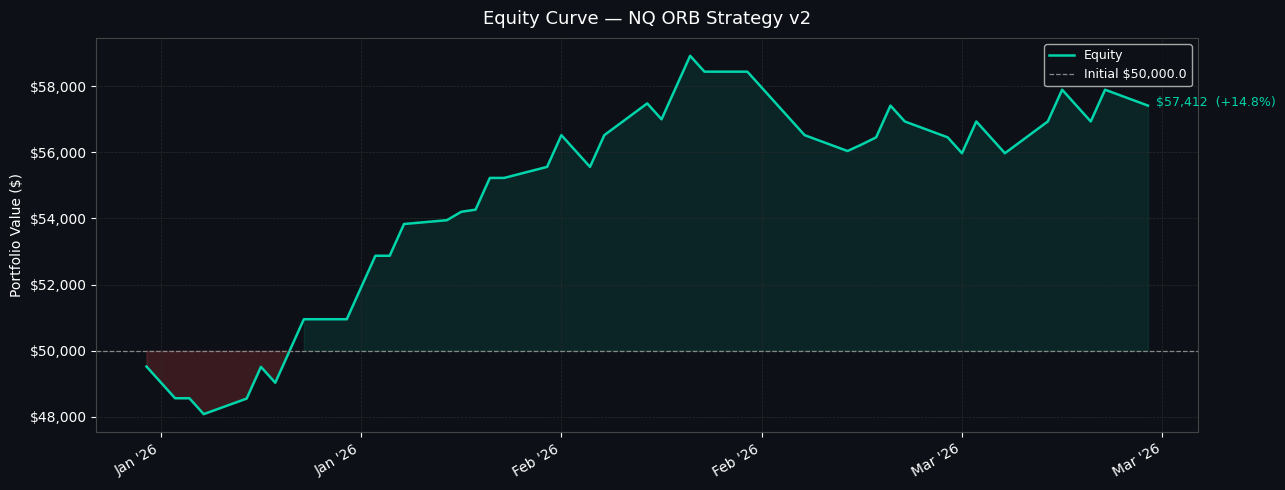

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(equity.index, equity.values, color='#00d4aa', linewidth=1.8, label='Equity')
ax.axhline(INITIAL_EQUITY, color='#888', linewidth=0.9, linestyle='--',
           label=f'Initial ${INITIAL_EQUITY:,}')

ax.fill_between(equity.index, INITIAL_EQUITY, equity.values,
                where=(equity.values >= INITIAL_EQUITY),
                color='#00d4aa', alpha=0.10)
ax.fill_between(equity.index, INITIAL_EQUITY, equity.values,
                where=(equity.values < INITIAL_EQUITY),
                color='#ff4444', alpha=0.18)

ax.annotate(
    f"  ${final_equity:,.0f}  ({total_return:+.1f}%)",
    xy=(equity.index[-1], equity.iloc[-1]),
    fontsize=9, color='#00d4aa',
)

ax.set_title('Equity Curve — NQ ORB Strategy v2', fontsize=13, pad=10)
ax.set_ylabel('Portfolio Value ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 5. Drawdown

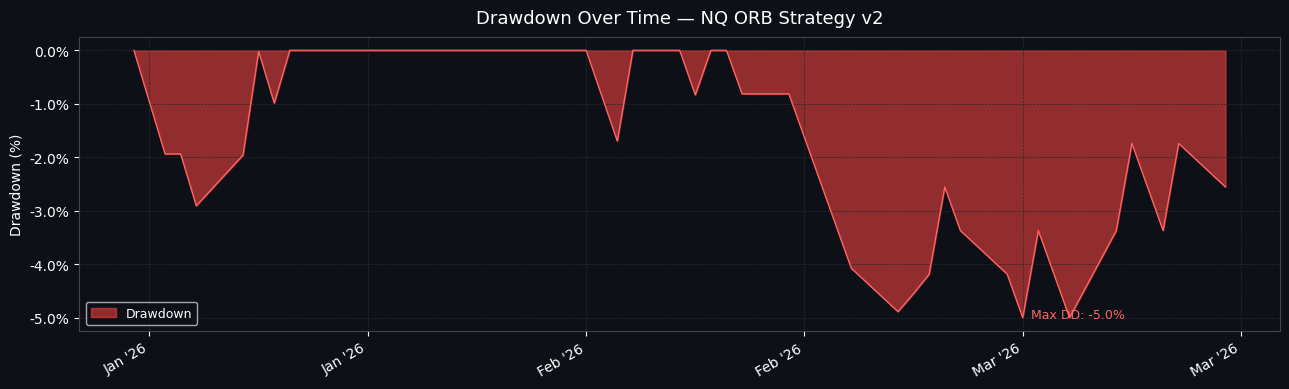

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(equity.index, drawdown_series.values, 0,
                color='#ff4444', alpha=0.55, label='Drawdown')
ax.plot(equity.index, drawdown_series.values, color='#ff6666', linewidth=0.9)

worst_idx = drawdown_series.idxmin()
ax.annotate(
    f"  Max DD: -{max_drawdown:.1f}%",
    xy=(worst_idx, drawdown_series[worst_idx]),
    fontsize=9, color='#ff6666',
)

ax.set_title('Drawdown Over Time — NQ ORB Strategy v2', fontsize=13, pad=10)
ax.set_ylabel('Drawdown (%)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

## 6. Trade Log

In [7]:
trades.style.applymap(
    lambda v: 'color: #00d4aa' if isinstance(v, (int, float)) and v > 0
              else ('color: #ff4444' if isinstance(v, (int, float)) and v < 0 else ''),
    subset=['pnl']
)

C:\Users\kunpa\AppData\Local\Temp\ipykernel_27732\156321837.py:1: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  trades.style.applymap(


,date,direction,entry_time,exit_time,exit_reason,entry_price,exit_price,contracts,pnl,equity_after
0,2026-01-05,LONG,2026-01-05 11:50:00-05:00,2026-01-05 12:20:00-05:00,SL,25702.500000,25642.500000,4,-480.000000,49520.000000
1,2026-01-06,LONG,2026-01-06 10:25:00-05:00,2026-01-06 10:50:00-05:00,SL,25763.250000,25703.250000,4,-480.000000,49040.000000
2,2026-01-07,LONG,2026-01-07 10:35:00-05:00,2026-01-07 10:35:00-05:00,SL,25882.000000,25822.000000,4,-480.000000,48560.000000
3,2026-01-09,SHORT,2026-01-09 10:10:00-05:00,2026-01-09 10:10:00-05:00,SL,25642.250000,25702.250000,4,-480.000000,48080.000000
4,2026-01-12,LONG,2026-01-12 11:10:00-05:00,2026-01-12 15:45:00-05:00,EOD,25925.500000,25984.250000,4,470.000000,48550.000000
5,2026-01-13,SHORT,2026-01-13 10:05:00-05:00,2026-01-13 10:45:00-05:00,TP,25930.500000,25810.500000,4,960.000000,49510.000000
6,2026-01-14,SHORT,2026-01-14 10:05:00-05:00,2026-01-14 10:10:00-05:00,SL,25556.250000,25616.250000,4,-480.000000,49030.000000
7,2026-01-15,SHORT,2026-01-15 14:15:00-05:00,2026-01-15 15:15:00-05:00,TP,25839.500000,25719.500000,4,960.000000,49990.000000
8,2026-01-16,SHORT,2026-01-16 10:15:00-05:00,2026-01-16 10:40:00-05:00,TP,25720.500000,25600.500000,4,960.000000,50950.000000
9,2026-01-20,SHORT,2026-01-20 13:35:00-05:00,2026-01-20 15:40:00-05:00,TP,25226.750000,25106.750000,4,960.000000,51910.000000
